# Heterogeneous Random-Line Scattering Demo

This notebook computes the uniform random-line scattering result inside the notebook, then applies the independent heterogeneous-mask layer for several `k_H/<k>` and clipping levels `b`.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

import rw_line_scattering as rls
import rw_hetero_demo as demo

plt.rcParams.update({"figure.dpi": 120})


## Parameter Settings

The radial line-wave spectrum is constructed here, and the uniform `I_L(Q)` calculation below uses these settings directly.

In [2]:
# Line-wave spectrum used for the uniform random-line calculation.
k0_nominal = 1.0
k_distribution = "gaussian_radial"
num_modes_k = 2**10
r_sigma_k = 0.2
random_seed = 12345

# Options: "qmc", "random", or "quadrature".
k_sampling = "qmc"

# Heterogeneous parameter grid for the saved demo outputs.
K_H_OVER_K_VALUES = (0.20,)
B_VALUES = (-1.0,)

# Single-case parameters for the Quick View panel.
QUICK_K_H_OVER_K = 0.10
QUICK_B = -1.0

# Joint scan parameters. These recompute the uniform line result for each
# r_sigma_k, then apply every clipping level at the fixed mask wavenumber.
SCAN_K_H_OVER_K = 0.10
SCAN_R_SIGMA_K_VALUES = (0.5, 0.3, 0.2)
SCAN_B_VALUES = (-2.0, -1.0, 0.0)

# Output location for saved arrays, per-case tables, and plot PNGs.
output_dir = Path("smpl/rw_hetero_demo_output")

# Real-space grid for M_J(r) -> C_L(r) -> I_L(Q).
# "mixed" is nonuniform: dense at small r, coarser in the long tail.
r_grid_mode = "mixed"
r_min_factor = 2.0e-3
r_split_factor = 5.0
r_max_factor = 250.0
Nr = 3000
Nr_small = 1200

# Q grid for the final intensity. The plotted convention is Q/<k>.
Q_min_factor = 0.05
Q_max_factor = 20.0
NQ = 256

# Conditional-Jacobian sampling controls.
N_samp_U = 2**14
N_samp_st = 2**6
jacobian_method = "direct_12d"

# Low-Q stabilization of the uniform line intensity before applying the mask.
# Fit/replace bounds are expressed in Q/<k>, where <k> is the spectrum mean.
use_lowq_stitch = True
lowq_fit_min_over_k = 0.35
lowq_fit_max_over_k = 0.80
lowq_replace_max_over_k = 0.50


## Intended Workflow

The uniform line result is computed once, then reused for any number of heterogeneous-mask parameter sets. The smooth approximation is the full calculated-`Q` model. The high-`Q` expression is a separate asymptotic diagnostic intended only for sufficiently large `Q`.

In [3]:
line_result = demo.compute_uniform_line_scattering(
    k0_nominal=k0_nominal,
    k_distribution=k_distribution,
    num_modes_k=num_modes_k,
    r_sigma_k=r_sigma_k,
    random_seed=random_seed,
    k_sampling=k_sampling,
    Nr=Nr,
    NQ=NQ,
    r_min_factor=r_min_factor,
    r_max_factor=r_max_factor,
    Q_min_factor=Q_min_factor,
    Q_max_factor=Q_max_factor,
    N_samp_U=N_samp_U,
    N_samp_st=N_samp_st,
    r_grid_mode=r_grid_mode,
    r_split_factor=r_split_factor,
    Nr_small=Nr_small,
    jacobian_method=jacobian_method,
    use_asymptotic=use_lowq_stitch,
    lowq_fit_bounds_over_k=(lowq_fit_min_over_k, lowq_fit_max_over_k),
    lowq_replace_max_over_k=lowq_replace_max_over_k,
    progress=True,
)

k = float(line_result.uniform_meta["k_mean"])
quick_k_H_over_k = QUICK_K_H_OVER_K
quick_b = QUICK_B
q_max = float(np.max(line_result.Q_grid))

quick_case = demo.evaluate_heterogeneous_case(
    line_result,
    k_h_over_k=quick_k_H_over_k,
    b=quick_b,
    q_max=q_max,
)
heterogeneous_result = quick_case["smooth"]
high_q_result = quick_case["high_q"]
k_H = float(quick_case["k_H"])
b = float(quick_case["b"])

print(f"rho0={line_result.rho0:.8g}, mu2={line_result.mu2:.8g}, <k>={k:.8g}")
print(f"k_H/<k>={quick_k_H_over_k:.8g}, b={quick_b:.8g}")
print(f"p_H={heterogeneous_result.p_H:.8g}, sigma_H^2={heterogeneous_result.sigma_H_squared:.8g}")
print(f"alpha_H={heterogeneous_result.alpha_H:.8g}, kappa_H={heterogeneous_result.kappa_H:.8g}")
print(
    f"low-Q stitch={use_lowq_stitch}, "
    f"fit Q/<k>={line_result.lowQ_fit_min/k:.3g}..{line_result.lowQ_fit_max/k:.3g}, "
    f"replace Q/<k><={line_result.lowQ_replace_max/k:.3g}, "
    f"fit rmse={line_result.lowQ_relative_rmse:.3g}"
)


M_J direct_12d: 150/3001 r values (0.4s)
M_J direct_12d: 300/3001 r values (0.8s)
M_J direct_12d: 450/3001 r values (1.2s)
M_J direct_12d: 600/3001 r values (1.6s)
M_J direct_12d: 750/3001 r values (2.1s)
M_J direct_12d: 900/3001 r values (2.5s)
M_J direct_12d: 1050/3001 r values (2.9s)
M_J direct_12d: 1200/3001 r values (3.4s)
M_J direct_12d: 1350/3001 r values (3.8s)
M_J direct_12d: 1500/3001 r values (4.2s)
M_J direct_12d: 1650/3001 r values (4.6s)
M_J direct_12d: 1800/3001 r values (5.0s)
M_J direct_12d: 1950/3001 r values (5.4s)
M_J direct_12d: 2100/3001 r values (5.9s)
M_J direct_12d: 2250/3001 r values (6.3s)
M_J direct_12d: 2400/3001 r values (6.7s)
M_J direct_12d: 2550/3001 r values (7.1s)
M_J direct_12d: 2700/3001 r values (7.6s)
M_J direct_12d: 2850/3001 r values (7.9s)
M_J direct_12d: 3000/3001 r values (8.3s)
M_J direct_12d: 3001/3001 r values (8.3s)
rho0=0.11027662, mu2=1.0393327, <k>=0.99967777
k_H/<k>=0.1, b=-1
p_H=0.84134475, sigma_H^2=0.13348376
alpha_H=0.0055715021, 

## Run The Full Demo Grid

The grid evaluates the explicit notebook parameter sets `K_H_OVER_K_VALUES` and `B_VALUES`. It saves a structured compressed `.npz` plus plot PNGs under `rw_hetero_demo_output/`.


In [4]:
data = demo.evaluate_heterogeneous_grid(
    line_result,
    k_h_over_k_values=K_H_OVER_K_VALUES,
    b_values=B_VALUES,
    q_max=q_max,
)
demo.save_results(data, output_dir)
demo.make_plots(data, output_dir)
print(output_dir / "rw_hetero_demo_data.npz")

print(
    f"stored low-Q fit Q/<k>={data['lowQ_fit_min']/data['k_mean']:.3g}..{data['lowQ_fit_max']/data['k_mean']:.3g}, "
    f"replace Q/<k><={data['lowQ_replace_max']/data['k_mean']:.3g}"
)


smpl\rw_hetero_demo_output\rw_hetero_demo_data.npz
stored low-Q fit Q/<k>=0.35..0.8, replace Q/<k><=0.5


## Data Fields

The saved file contains the freshly computed uniform arrays (`r_grid`, `M_J`, `C_L`, `Q`, `I_L`), `I_h_smooth`, `I_h_highQ`, each smooth-model component, the mask parameters, spectrum settings, `rho0`, `mu2`, and the numerical cutoff `Q_max`.

In [5]:
saved = np.load(output_dir / "rw_hetero_demo_data.npz")
for key in saved.files:
    value = saved[key]
    print(f"{key}: shape={value.shape}, dtype={value.dtype}")

Q: shape=(256,), dtype=float64
I_L: shape=(256,), dtype=float64
I_L_original: shape=(256,), dtype=float64
I_L_lowQ_asymptotic: shape=(256,), dtype=float64
lowQ_fit_mask: shape=(256,), dtype=bool
lowQ_replaced_mask: shape=(256,), dtype=bool
lowQ_I0: shape=(), dtype=float64
lowQ_I2: shape=(), dtype=float64
lowQ_fit_min: shape=(), dtype=float64
lowQ_fit_max: shape=(), dtype=float64
lowQ_replace_max: shape=(), dtype=float64
lowQ_relative_rmse: shape=(), dtype=float64
use_asymptotic: shape=(), dtype=bool
r_grid: shape=(3001,), dtype=float64
M_J: shape=(3001,), dtype=float64
C_L: shape=(3001,), dtype=float64
I_h_smooth: shape=(1, 1, 256), dtype=float64
I_h_highQ: shape=(1, 1, 256), dtype=float64
weighted_line_component: shape=(1, 1, 256), dtype=float64
smoothed_line_component: shape=(1, 1, 256), dtype=float64
mask_only_component: shape=(1, 1, 256), dtype=float64
k_H_over_k: shape=(1,), dtype=float64
k_H: shape=(1,), dtype=float64
b: shape=(1,), dtype=float64
p_H: shape=(1, 1), dtype=float64


## Quick View

This cell shows one explicit heterogeneous case computed directly from `line_result`, without selecting from or scanning the saved grid.


Quick view: k_H/<k>=0.1 b=-1 r_sigma_k=0.2 low-Q stitch=True


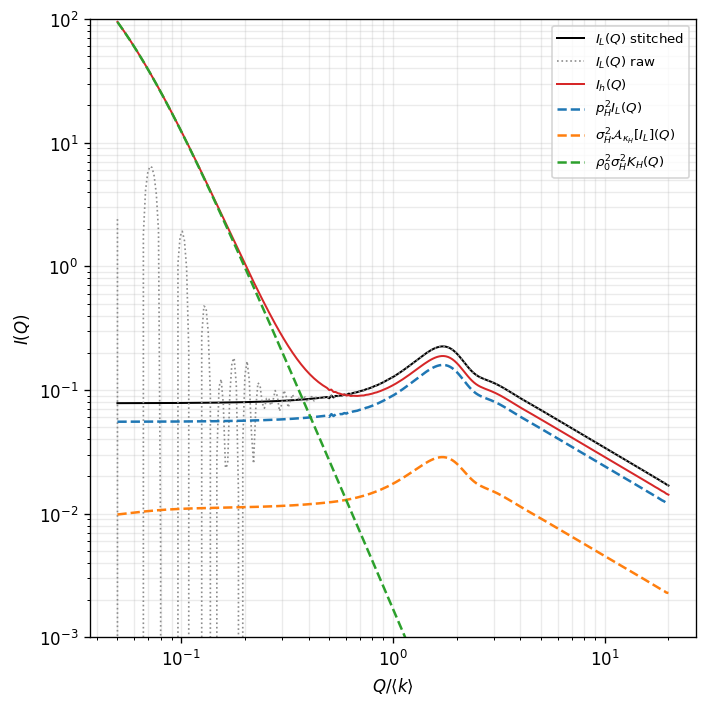

In [6]:
Q = line_result.Q_grid
k = float(line_result.uniform_meta["k_mean"])

print(
    "Quick view:",
    f"k_H/<k>={quick_k_H_over_k:.3g}",
    f"b={quick_b:.3g}",
    f"r_sigma_k={r_sigma_k:.3g}",
    f"low-Q stitch={use_lowq_stitch}",
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.loglog(Q / k, line_result.I_L, color="black", lw=1.2, label=r"$I_L(Q)$ stitched")
if use_lowq_stitch:
    ax.loglog(Q / k, line_result.I_L_original, color="0.55", lw=1.0, ls=":", label=r"$I_L(Q)$ raw")
ax.loglog(Q / k, heterogeneous_result.I_h, color="tab:red", lw=1.2, label=r"$I_h(Q)$")
ax.loglog(Q / k, heterogeneous_result.uniform_component, label=r"$p_H^2 I_L(Q)$", linestyle="--")
ax.loglog(
    Q / k,
    heterogeneous_result.smoothed_line_component,
    label=r"$\sigma_H^2\mathcal{A}_{\kappa_H}[I_L](Q)$",
    linestyle="--",
)
ax.loglog(
    Q / k,
    heterogeneous_result.mask_component,
    label=r"$\rho_0^2\sigma_H^2K_H(Q)$",
    linestyle="--",
)

ax.set_xlabel(r"$Q/\langle k\rangle$")
ax.set_ylabel(r"$I(Q)$")
ax.set_ylim(1e-3, 1e2)
ax.legend(fontsize=8)
ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()


## Scan `r_sigma_k` And `b` At Fixed `k_H/<k>`

Fix `SCAN_K_H_OVER_K`, then scan `SCAN_R_SIGMA_K_VALUES` and `SCAN_B_VALUES`. This block recomputes the uniform line result once for each `r_sigma_k`, applies all clipping levels, and stores the final smooth result `I_h` for the two plot views below.


In [7]:
fixed_kH_over_k = SCAN_K_H_OVER_K
r_sigma_scan_values = SCAN_R_SIGMA_K_VALUES
b_scan_values = SCAN_B_VALUES
sigma_b_scan_results = {}

for sigma_value in r_sigma_scan_values:
    print(f"[status] computing uniform I_L for r_sigma_k={sigma_value}")
    scan_line_result = demo.compute_uniform_line_scattering(
        k0_nominal=k0_nominal,
        k_distribution=k_distribution,
        num_modes_k=num_modes_k,
        r_sigma_k=sigma_value,
        random_seed=random_seed,
        k_sampling=k_sampling,
        Nr=Nr,
        NQ=NQ,
        r_min_factor=r_min_factor,
        r_max_factor=r_max_factor,
        Q_min_factor=Q_min_factor,
        Q_max_factor=Q_max_factor,
        N_samp_U=N_samp_U,
        N_samp_st=N_samp_st,
        r_grid_mode=r_grid_mode,
        r_split_factor=r_split_factor,
        Nr_small=Nr_small,
        jacobian_method=jacobian_method,
        use_asymptotic=use_lowq_stitch,
        lowq_fit_bounds_over_k=(lowq_fit_min_over_k, lowq_fit_max_over_k),
        lowq_replace_max_over_k=lowq_replace_max_over_k,
        progress=True,
    )
    scan_k = float(scan_line_result.uniform_meta["k_mean"])
    for b_value in b_scan_values:
        print(
            f"[status] applying heterogeneous layer for k_H/<k>={fixed_kH_over_k:g}, "
            f"r_sigma_k={sigma_value}, b={b_value:g}"
        )
        scan_case = demo.evaluate_heterogeneous_case(
            scan_line_result,
            k_h_over_k=fixed_kH_over_k,
            b=b_value,
            q_max=float(np.max(scan_line_result.Q_grid)),
        )
        sigma_b_scan_results[(sigma_value, b_value)] = (
            scan_k,
            scan_line_result,
            scan_case["smooth"],
        )

print("[status] joint r_sigma_k and b scan data ready")


[status] computing uniform I_L for r_sigma_k=0.5
M_J direct_12d: 150/3001 r values (0.3s)
M_J direct_12d: 300/3001 r values (0.7s)
M_J direct_12d: 450/3001 r values (1.0s)
M_J direct_12d: 600/3001 r values (1.3s)
M_J direct_12d: 750/3001 r values (1.6s)
M_J direct_12d: 900/3001 r values (1.9s)
M_J direct_12d: 1050/3001 r values (2.3s)
M_J direct_12d: 1200/3001 r values (2.6s)
M_J direct_12d: 1350/3001 r values (3.0s)
M_J direct_12d: 1500/3001 r values (3.4s)
M_J direct_12d: 1650/3001 r values (3.8s)
M_J direct_12d: 1800/3001 r values (4.1s)
M_J direct_12d: 1950/3001 r values (4.5s)
M_J direct_12d: 2100/3001 r values (4.8s)
M_J direct_12d: 2250/3001 r values (5.2s)
M_J direct_12d: 2400/3001 r values (5.5s)
M_J direct_12d: 2550/3001 r values (5.8s)
M_J direct_12d: 2700/3001 r values (6.2s)
M_J direct_12d: 2850/3001 r values (6.5s)
M_J direct_12d: 3000/3001 r values (6.8s)
M_J direct_12d: 3001/3001 r values (6.8s)
[status] applying heterogeneous layer for k_H/<k>=0.1, r_sigma_k=0.5, b=-2


[status] joint r_sigma_k and b scan plot complete


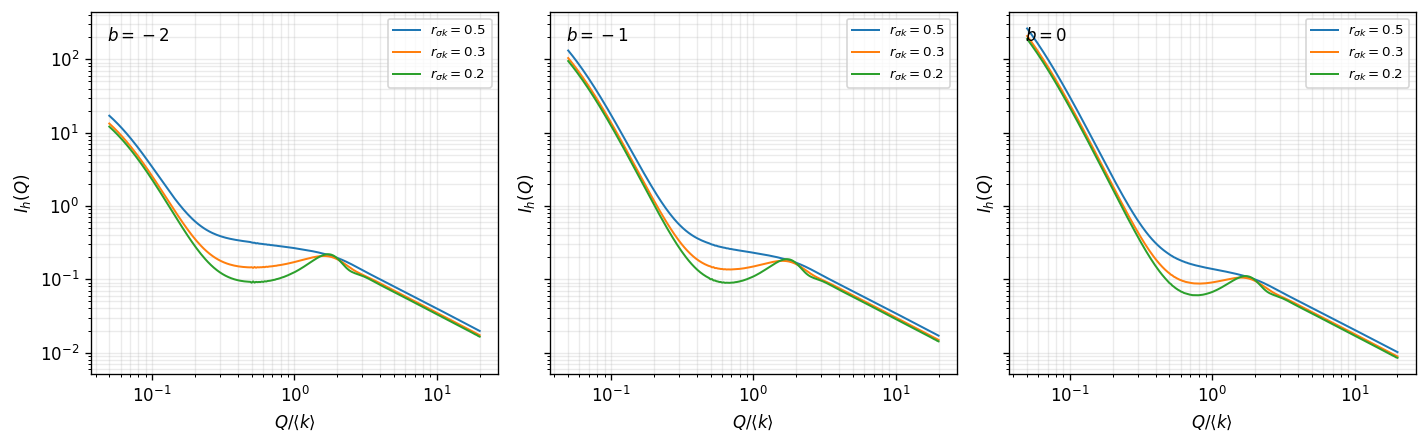

In [8]:
if "sigma_b_scan_results" not in globals():
    raise RuntimeError("Run the joint r_sigma_k/b scan cell before plotting this view.")

fig, axes = plt.subplots(1, len(b_scan_values), figsize=(12.0, 3.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, b_value in zip(axes, b_scan_values):
    for sigma_value in r_sigma_scan_values:
        scan_k, scan_line_result, scan_hetero = sigma_b_scan_results[(sigma_value, b_value)]
        Q_scan = scan_line_result.Q_grid
        ax.loglog(
            Q_scan / scan_k,
            scan_hetero.I_h,
            lw=1.2,
            label=rf"$r_{{\sigma k}}={sigma_value:g}$",
        )
    ax.set_xlabel(r"$Q/\langle k\rangle$")
    ax.set_ylabel(r"$I_h(Q)$")
    ax.text(0.04, 0.92, rf"$b={b_value:g}$", transform=ax.transAxes)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
print("[status] joint r_sigma_k and b scan plot complete")


## Same Scan Grouped By `r_sigma_k`

This view uses the same fixed `k_H/<k>=0.1` joint scan above, but groups curves by `r_sigma_k` so the effect of changing `b` is easier to compare.


[status] grouped b view complete


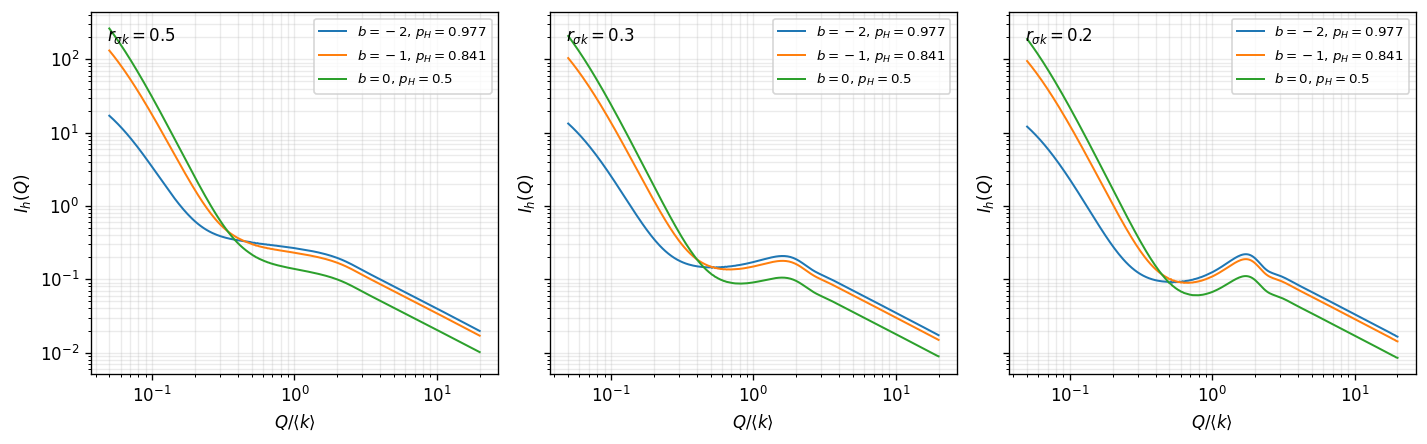

In [9]:
if "sigma_b_scan_results" not in globals():
    raise RuntimeError("Run the joint r_sigma_k/b scan cell before plotting this view.")

fig, axes = plt.subplots(1, len(r_sigma_scan_values), figsize=(12.0, 3.8), sharey=True)
axes = np.atleast_1d(axes)
for ax, sigma_value in zip(axes, r_sigma_scan_values):
    for b_value in b_scan_values:
        scan_k, scan_line_result, scan_hetero = sigma_b_scan_results[(sigma_value, b_value)]
        Q_scan = scan_line_result.Q_grid
        ax.loglog(
            Q_scan / scan_k,
            scan_hetero.I_h,
            lw=1.2,
            label=rf"$b={b_value:g}$, $p_H={scan_hetero.p_H:.3g}$",
        )
    ax.set_xlabel(r"$Q/\langle k\rangle$")
    ax.set_ylabel(r"$I_h(Q)$")
    ax.text(0.04, 0.92, rf"$r_{{\sigma k}}={sigma_value:g}$", transform=ax.transAxes)
    ax.legend(fontsize=8)
    ax.grid(True, which="both", alpha=0.25)
fig.tight_layout()
print("[status] grouped b view complete")
